# Corrective RAG(CRAG)란?
Corrective RAG는 검색된 문서의 **관련성을 평가**하고, 관련성이 낮을 경우 **웹 검색을 통해 보완**하는 고급 RAG 기법입니다.


## 주요 개념

1. **문서 관련성 평가**: 검색된 문서가 질문과 얼마나 관련이 있는지 평가
2. **웹 검색 보완**: 관련성이 낮은 경우 웹 검색을 통해 추가 정보 수집
3. **결과 통합**: 벡터 검색 결과와 웹 검색 결과를 통합하여 최종 답변 생성
4. **신뢰도 기반 응답**: 검색 결과의 신뢰도에 따라 답변 생성


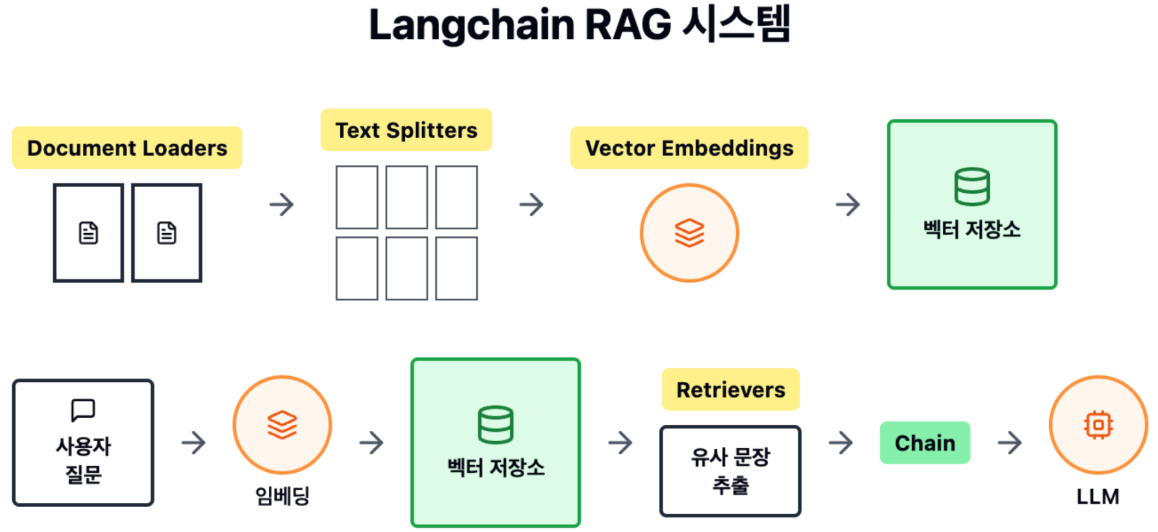

## Adaptive RAG vs Corrective RAG

- **Adaptive RAG**: 질문의 복잡도에 따라 다른 검색 전략 선택
- **Corrective RAG**: 검색 결과의 관련성을 평가하고 필요시 웹 검색으로 보완


## Vector Store


### Embedding Model

In [ ]:
from langchain_ollama import OllamaEmbeddings

embeddings_ollama = OllamaEmbeddings(model="qwen3-embedding:0.6b")


### Qdrant VectorStore


In [3]:
from qdrant_client import QdrantClient
from langchain_qdrant import QdrantVectorStore

vectorstore = QdrantVectorStore(
    client=QdrantClient(host="localhost", port=6333),
    collection_name="rag_keywords",
    embedding=embeddings_model,
)


In [4]:
results = vectorstore.similarity_search("TF IDF 에 대하여 알려줘", k=3)

for i, doc in enumerate(results, 1):
    print(f"{i}. {doc.page_content}")
    print(f"   메타데이터: {doc.metadata}")
    print()


1. 정의: TF-IDF는 문서 내에서 단어의 중요도를 평가하는 데 사용되는 통계적 척도입니다. 이는 문서 내 단어의 빈도와 전체 문서 집합에서 그 단어의 희소성을 고려합니다.
예시: 많은 문서에서 자주 등장하지 않는 단어는 높은 TF-IDF 값을 가집니다.
연관키워드: 자연어 처리, 정보 검색, 데이터 마이닝

Deep Learning
   메타데이터: {'source': './data/rag-keywords.txt', '_id': 'd68cdab2-3e59-48de-a864-6985fa57e7b5', '_collection_name': 'rag_keywords'}

2. JSON

정의: JSON(JavaScript Object Notation)은 경량의 데이터 교환 형식으로, 사람과 기계 모두에게 읽기 쉬운 텍스트를 사용하여 데이터 객체를 표현합니다.
예시: {"이름": "홍길동", "나이": 30, "직업": "개발자"}는 JSON 형식의 데이터입니다.
연관키워드: 데이터 교환, 웹 개발, API

Transformer
   메타데이터: {'source': './data/rag-keywords.txt', '_id': '68936fbf-a87d-4582-8bbc-20aed525a2e0', '_collection_name': 'rag_keywords'}

3. DataFrame

정의: DataFrame은 행과 열로 이루어진 테이블 형태의 데이터 구조로, 주로 데이터 분석 및 처리에 사용됩니다.
예시: 판다스 라이브러리에서 DataFrame은 다양한 데이터 타입의 열을 가질 수 있으며, 데이터 조작과 분석을 용이하게 합니다.
연관키워드: 데이터 분석, 판다스, 데이터 처리

Attention 메커니즘
   메타데이터: {'source': './data/rag-keywords.txt', '_id': '94cb5043-5b72-4877-b733-806c1e355de0', '_collection_name': 'rag_keywords'}



## Corrective RAG 구현


### TavilySearch를 이용한 Tool 생성
> TavilySearch는 실시간 웹 검색을 수행할 수 있는 도구입니다. 최신 정보를 검색하고 요약할 수 있습니다.

핵심 포인트:
1. **실시간 검색**: 최신 정보를 실시간으로 검색
2. **다양한 소스**: 뉴스, 날씨, 주식 등 다양한 정보 소스 활용
3. **검색 최적화**: max_results, search_depth 등으로 검색 품질 조절
4. **LCEL 통합**: 다른 도구들과 함께 사용하여 강력한 정보 분석 시스템 구축

### API Key 등록 및 적용 
- [Tavily API Key](https://app.tavily.com/home)
- [OpenAI Key 발급](https://platform.openai.com/api-keys)

In [ ]:
from dotenv import load_dotenv

load_dotenv()

### LLM 초기화


In [5]:
from langchain_openai import ChatOpenAI

# LLM 초기화
llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### 기본 Retriever 설정


In [6]:
# 기본 retriever 생성
base_retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)


### 문서 관련성 평가기 구현

검색된 문서가 질문과 얼마나 관련이 있는지 평가합니다.


> 관련성 평가 프롬프트


In [7]:
from langchain_core.prompts import ChatPromptTemplate

# 문서 관련성 평가 프롬프트 (엄격한 평가)
correctness_prompt = ChatPromptTemplate.from_messages([
    ("system", 
    """
        당신은 문서의 관련성을 엄격하게 평가하는 전문가입니다.
        주어진 질문과 검색된 문서를 비교하여 관련성을 평가하세요.

        **엄격한 평가 기준:**
        1. 문서 내용만으로 질문에 대한 구체적이고 명확한 답변을 제공할 수 있는가?
        2. 문서가 질문에 대한 충분하고 정확한 정보를 포함하고 있는가?

        다음 중 하나로 평가하세요:
        1. RELEVANT: 문서가 질문에 대한 구체적이고 충분한 답변을 제공할 수 있음
        2. IRRELEVANT: 문서가 질문과 관련이 없으면 답변을 제공할 수 없음

        반드시 RELEVANT 또는 IRRELEVANT 중 하나만 출력하세요."""),
    ("human", 
    """
        질문: {question}
        
        문서:
        {documents}
        
        평가:""")
])


> 관련성 평가 체인


In [8]:
from langchain_core.output_parsers import StrOutputParser

# 관련성 평가 체인
correctness_chain = correctness_prompt | llm | StrOutputParser()


> 관련성 평가 함수


In [9]:
def evaluate_relevance(question: str, documents: list) -> tuple[bool, list]:
    """
    검색된 문서들의 관련성을 엄격하게 평가합니다.
    
    Returns:
        (is_relevant, relevant_docs): 관련성 여부와 관련 문서 리스트
    """
    if not documents:
        return False, []
    
    # 문서들을 하나의 텍스트로 합치기
    docs_text = "\n\n".join([f"[문서 {i+1}]\n{doc.page_content}" for i, doc in enumerate(documents)])
    
    # 관련성 평가
    try:
        result = correctness_chain.invoke({
            "question": question,
            "documents": docs_text
        })
        
        result_upper = result.upper().strip()
        # RELEVANT가 포함되어 있고 IRRELEVANT가 명시적으로 없는 경우만 관련 있음
        is_relevant = "RELEVANT" in result_upper and "IRRELEVANT" not in result_upper
        
        if is_relevant:
            print(f"[CRAG] 관련성 평가: RELEVANT - {len(documents)}개 문서 사용")
            print(f"[CRAG] 평가 결과: {result.strip()[:150]}...")
            return True, documents
        else:
            print(f"[CRAG] 관련성 평가: IRRELEVANT - 웹 검색 필요")
            print(f"[CRAG] 평가 결과: {result.strip()[:150]}...")
            return False, []
    except Exception as e:
        print(f"[CRAG] 관련성 평가 중 오류 발생: {e}")
        # 오류 발생 시 안전하게 웹 검색을 사용하도록 함
        print(f"[CRAG] 오류로 인해 웹 검색으로 전환")
        return False, []


### 웹 검색 구현

관련성이 낮은 경우 웹 검색을 통해 추가 정보를 수집합니다.


> 웹 검색 함수 (시뮬레이션)

실제 웹 검색 API를 사용하지 않고, 시뮬레이션으로 구현합니다.
실제 환경에서는 Tavily, Serper, Google Search API 등을 사용할 수 있습니다.


In [18]:
from langchain_core.documents import Document
from langchain_tavily import TavilySearch

def web_search(question: str, max_results: int = 3) -> list[Document]:
    """
    웹 검색을 시뮬레이션합니다.
    실제 환경에서는 Tavily, Serper 등의 API를 사용합니다.
    """
    print(f"[CRAG] 웹 검색 실행: {question}")
    
    # 실제 환경에서는 다음과 같이 사용:
    
    search = TavilySearch(
        max_results=max_results,
        include_answer=True,           # 답변 포함 여부
        include_raw_content=False,     # 원본 내용 포함 여부
        include_images=False,          # 이미지 포함 여부
        search_depth="advanced",          # "basic" 또는 "advanced"
        include_domains=[
            "wikipedia.org",
            "stackoverflow.com",
            "github.com",
            "huggingface.co"
        ],
        exclude_domains=None            # 필요하면 제외 도메인 지정 가능
    )
    web_results = search.invoke({"query": question})
    return [Document(page_content=r["content"], metadata={"source": r["url"]}) for r in web_results['results']]
    

### Corrective RAG 체인 구현

LCEL을 사용하여 문서 관련성 평가와 웹 검색을 통합한 RAG 체인을 구현합니다.


> 문서 포맷팅 함수


In [19]:
def format_docs(docs):
    """검색된 문서를 포맷팅하고 출처 정보 추가"""
    if not docs:
        return "관련 문서를 찾을 수 없습니다.", []
    
    formatted_texts = []
    sources = []
    
    for i, doc in enumerate(docs, 1):
        title = doc.metadata.get("title", "Unknown")
        source = doc.metadata.get("source", "Unknown")
        formatted_texts.append(f"[문서 {i}: {title}]\n{doc.page_content}")
        sources.append(source)
    
    return "\n\n".join(formatted_texts), list(set(sources))  # 중복 제거


> Corrective Retriever 함수


In [20]:
def corrective_retriever(input_dict):
    """
    문서 관련성을 평가하고, 필요시 웹 검색을 수행합니다.
    """
    question = input_dict["question"]
    
    # 1단계: 벡터 검색
    print(f"\n[CRAG] 벡터 검색 시작: {question}")
    retrieved_docs = base_retriever.invoke(question)
    
    # 2단계: 관련성 평가
    is_relevant, relevant_docs = evaluate_relevance(question, retrieved_docs)
    
    # 3단계: 관련성이 낮으면 웹 검색 수행
    if not is_relevant or len(relevant_docs) == 0:
        print("[CRAG] 웹 검색을 통해 추가 정보 수집")
        web_docs = web_search(question)
        return web_docs
    else:
        print(f"[CRAG] 벡터 검색 결과 사용: {len(relevant_docs)}개 문서")
        return relevant_docs


> RAG 프롬프트


In [21]:
# RAG 프롬프트
rag_prompt = ChatPromptTemplate.from_messages([
    ("system", 
    """
        당신은 RAG, NLP, AI 관련 질문에 답변하는 전문 어시스턴트입니다.

        다음 규칙을 따르세요:
        1. 제공된 컨텍스트만을 기반으로 답변하세요.
        2. 컨텍스트에 관련 정보가 없으면 "죄송하지만, 제공된 정보에서는 해당 질문에 대한 답을 찾을 수 없습니다."라고 답변하세요.
        3. 답변은 명확하고 간결하게 작성하세요.
        4. 예시가 있다면 함께 설명해주세요.
        5. 웹 검색 결과가 포함된 경우, 이를 명시해주세요.

        컨텍스트:
        {context}"""),
    ("human", "{question}")
])


> 답변에 출처 추가 함수


In [22]:
# 답변에 출처 추가 함수
def add_sources(response_dict):
    """답변에 출처 정보 추가"""
    answer = response_dict["answer"]
    sources = response_dict["sources"]
    
    # 출처가 없거나, Unknown만 있거나, 답변이 "찾을 수 없습니다"를 포함하면 출처 추가 안함
    if not sources or sources == ["Unknown"] or "찾을 수 없습니다" in answer:
        return answer
    
    # Unknown을 제외한 실제 출처만 필터링
    valid_sources = [s for s in sources if s != "Unknown"]
    if not valid_sources:
        return answer
    
    source_text = "\n\n---\n**출처:**\n" + "\n".join([f"- {source}" for source in valid_sources])
    return answer + source_text

print("Corrective RAG 함수 정의 완료!")


Corrective RAG 함수 정의 완료!


> LCEL을 사용한 Corrective RAG 체인 구성


In [23]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

# LCEL을 사용한 Corrective RAG 체인 구성
corrective_rag_chain = (
    # 1단계: Corrective retrieval (관련성 평가 + 웹 검색)
    RunnablePassthrough.assign(
        docs=RunnableLambda(corrective_retriever)
    )
    # 2단계: 문서 포맷팅 및 출처 추출
    | RunnablePassthrough.assign(
        formatted=lambda x: format_docs(x["docs"])
    )
    # 3단계: context와 sources 분리
    | RunnablePassthrough.assign(
        context=lambda x: x["formatted"][0],
        sources=lambda x: x["formatted"][1]
    )
    # 4단계: RAG 답변 생성
    | RunnablePassthrough.assign(
        answer=(
            {
                "context": lambda x: x["context"],
                "question": lambda x: x["question"]
            }
            | rag_prompt
            | llm
            | StrOutputParser()
        )
    )
    # 5단계: 출처 추가
    | RunnableLambda(add_sources)
)

print("Corrective RAG 체인 구성 완료!")


Corrective RAG 체인 구성 완료!


### Corrective RAG 테스트

다양한 유형의 질문으로 Corrective RAG 시스템을 테스트합니다.


> 테스트 케이스 1: 관련 문서가 있는 질문


In [24]:
# 테스트 케이스 1: 관련 문서가 있는 질문
print("=" * 80)
print("테스트 1: 관련 문서가 있는 질문")
print("=" * 80)

question1 = "임베딩이란 무엇인가요?"
response1 = corrective_rag_chain.invoke({"question": question1})
print(f"\n질문: {question1}")
print(f"\n답변:\n{response1}")


테스트 1: 관련 문서가 있는 질문

[CRAG] 벡터 검색 시작: 임베딩이란 무엇인가요?
[CRAG] 관련성 평가: RELEVANT - 3개 문서 사용
[CRAG] 평가 결과: RELEVANT...
[CRAG] 벡터 검색 결과 사용: 3개 문서

질문: 임베딩이란 무엇인가요?

답변:
- 정의: 임베딩은 단어나 문장 같은 텍스트 데이터를 저차원의 연속적인 벡터로 변환하는 과정입니다. 이를 통해 컴퓨터가 텍스트를 이해하고 처리할 수 있게 합니다.
- 예시: "사과"라는 단어를 [0.65, -0.23, 0.17]와 같은 벡터로 표현합니다.
- 연관키워드: 자연어 처리, 벡터화, 딥러닝.

---
**출처:**
- ./data/rag-keywords.txt


> 테스트 케이스 2: 관련 문서가 없는 질문 (웹 검색 필요)


In [25]:
# 테스트 케이스 2: 관련 문서가 없는 질문 (웹 검색 필요)
print("\n\n" + "=" * 80)
print("테스트 2: 관련 문서가 없는 질문 (웹 검색 필요)")
print("=" * 80)

question2 = "허깅페이스에 등록된 Gemma3 모델에 대해서 간단하게 설명해줘."
response2 = corrective_rag_chain.invoke({"question": question2})
print(f"\n질문: {question2}")
print(f"\n답변:\n{response2}")




테스트 2: 관련 문서가 없는 질문 (웹 검색 필요)

[CRAG] 벡터 검색 시작: 허깅페이스에 등록된 Gemma3 모델에 대해서 간단하게 설명해줘.
[CRAG] 관련성 평가: IRRELEVANT - 웹 검색 필요
[CRAG] 평가 결과: IRRELEVANT...
[CRAG] 웹 검색을 통해 추가 정보 수집
[CRAG] 웹 검색 실행: 허깅페이스에 등록된 Gemma3 모델에 대해서 간단하게 설명해줘.

질문: 허깅페이스에 등록된 Gemma3 모델에 대해서 간단하게 설명해줘.

답변:
허깅페이스에 등록된 Gemma 3에 대한 간단한 설명(웹 소스 기반)

- 개요: 구글 디엠의 오픈 가중치 멀티모달 LLM로, 허깅페이스에 공개되어 있음. base(사전학습) 버전과 instruction-tuned 버전 모두 오픈 가중치로 제공되는 것이 특징.
- 파라미터 크기: 1B, 4B, 12B, 27B의 네 가지 크기.
- 입력 형식: 4B/12B/27B 모델은 텍스트와 이미지를 함께 처리할 수 있고, 1B 모델은 텍스트만 처리합니다.
- 컨텍스트 창: 최대 128k 토큰의 긴 컨텍스트를 지원.
- 다국어 지원: 140+개 언어를 지원.
- 어텐션 방식: 텍스트 입력은 한 방향 주의(one-way attention)로 처리되며, 이미지는 전체 주의(full attention, 마스크 없음)로 이해합니다.
- 용도: 텍스트 생성, 이미지 이해, 질의응답, 요약, 추론 등 다양한 작업에 사용 가능.
- 이용 주의: 오픈 가중치이지만 사용 조건은 허깅페이스 페이지의 이용 약관을 확인해야 함.

참고 소스: Hugging Face의 Gemma 3 소개 글 및 관련 문서에 기반합니다.

---
**출처:**
- https://huggingface.co/blog/gemma3
- https://huggingface.co/google/gemma-3-270m-it
- https://github.com/huggingface/blog/blob/main/gemma3.md


> 테스트 케이스 3: 복잡한 질문


In [26]:
# 테스트 케이스 3: 복잡한 질문
print("\n\n" + "=" * 80)
print("테스트 3: 복잡한 질문")
print("=" * 80)

question3 = "Semantic Search와 Keyword Search의 차이점을 비교하고, 각각 어떤 상황에서 사용하면 좋을지 설명해주세요."
response3 = corrective_rag_chain.invoke({"question": question3})
print(f"\n질문: {question3}")
print(f"\n답변:\n{response3}")




테스트 3: 복잡한 질문

[CRAG] 벡터 검색 시작: Semantic Search와 Keyword Search의 차이점을 비교하고, 각각 어떤 상황에서 사용하면 좋을지 설명해주세요.
[CRAG] 관련성 평가: RELEVANT - 3개 문서 사용
[CRAG] 평가 결과: RELEVANT...
[CRAG] 벡터 검색 결과 사용: 3개 문서

질문: Semantic Search와 Keyword Search의 차이점을 비교하고, 각각 어떤 상황에서 사용하면 좋을지 설명해주세요.

답변:
다음과 같이 차이를 정리하고, 상황별 사용 가이드를 제시합니다.

1) Semantic Search와 Keyword Search의 차이점
- Semantic Search
  - 정의: 사용자의 질의의 의미를 파악하여 의도에 맞는 관련 결과를 반환합니다.
  - 특징: 키워드 그 자체뿐 아니라 질의의 의미를 이해하고, 관련된 정보까지 연결해 제공합니다.
  - 예시: 사용자가 "태양계 행성"이라고 검색하면 목성, 화성 등과 같은 관련 행성 정보가 함께 나옵니다.
  - 연관 키워드: 자연어 처리, 검색 알고리즘, 데이터 마이닝

- Keyword Search
  - 정의: 사용자가 입력한 키워드를 기반으로 정보를 찾는 기본적인 검색 방식입니다.
  - 특징: 키워드 매칭에 초점을 맞추며, 질의의 의미까지 해석하지는 않습니다.
  - 예시: 사용자가 "커피숍 서울"이라고 검색하면 서울에 있는 커피숍 목록을 반환합니다.
  - 연관 키워드: 검색 엔진, 데이터 검색, 정보 검색

2) 각각 어떤 상황에서 사용하면 좋을지
- Semantic Search를 사용할 때
  - 질의가 자연어로 표현되고, 의도나 맥락을 이해해야 할 때
  - 단어의 동의어나 다른 표현으로도 관련 정보를 포괄적으로 찾고자 할 때
  - 데이터 마이닝이나 NLP를 활용해 의미 기반의 연결을 탐색하고자 할 때
  - 예시 상황: 사용자에게 다양한 연관 정보나 개념 간의 연결을 제시해야 하는 검색 서비스

- Ke